Present assumptions:
- psuedobulked on CRE (removing MPRA barcode heterogenaity). 
- untransfected zeroes are detectable and have been removed
- Chimeric transcripts have been removed
- No systemic differences in cell number, tfection efficiency btwn reps (should change)
- There ARE systemic differences in dropout between replicates

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns
import itertools

1000


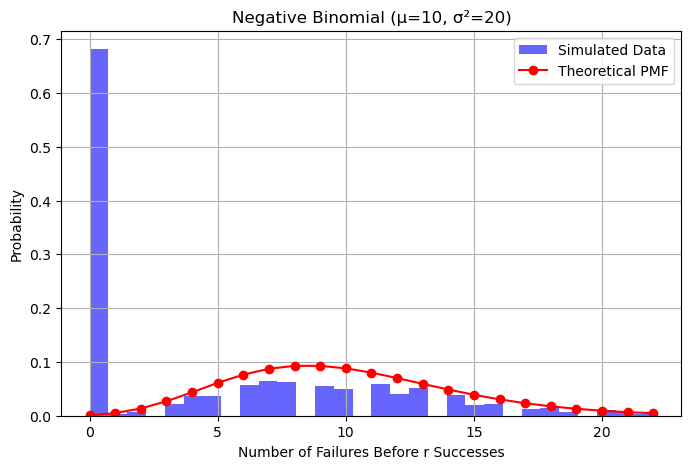

In [79]:

def plot_negative_binomial(samples, mu, sigma2):
    """
    Plot histogram and theoretical PMF of Negative Binomial distribution using mean and variance.
    """
    # Convert mean & variance to standard Negative Binomial parameters
    r = mu**2 / (sigma2 - mu)  # Number of successes
    p = mu / sigma2  # Probability of success

    plt.figure(figsize=(8, 5))
    plt.hist(samples, bins=30, density=True, alpha=0.6, color='b', label="Simulated Data")

    # Overlay theoretical Negative Binomial PMF
    x = np.arange(0, max(samples) + 1)
    pmf = stats.nbinom.pmf(x, r, p)
    plt.plot(x, pmf, 'ro-', label="Theoretical PMF")

    plt.xlabel("Number of Failures Before r Successes")
    plt.ylabel("Probability")
    plt.title(f"Negative Binomial (μ={mu}, σ²={sigma2})")
    plt.legend()
    plt.grid()
    plt.show()

def draw_nb(mu, sigma2, size):
    """
    Draw samples from a Negative Binomial distribution using mean and variance.

    Args:
        mu (float): Desired mean.
        sigma2 (float): Desired variance (must be > mu).
        size (int): Number of samples to draw.

    Returns:
        samples (array): Generated samples.
    """
    if sigma2 <= mu:
        raise ValueError("Variance must be greater than the mean (sigma² > μ)")

    # Convert mean & variance to standard Negative Binomial parameters
    r = mu**2 / (sigma2 - mu)  # Number of successes
    p = mu / sigma2  # Probability of success

    samples = np.random.negative_binomial(n=r, p=p, size=size)
    
    return samples

def draw_zinb(mu, sigma2, zin, size):
    """
        Args:
            mu (float): Desired mean.
            sigma2 (float): Desired variance (must be > mu).
            zin (float): 0-1 Desired fraction zero inflation. 
            size (int): Number of samples to draw.
    """

    zin_size=round(size*zin)
    non_zin_size=size-zin_size
    
    zerolist=pd.Series([0]*zin_size)
    draws=draw_nb(mu=mu,sigma2=sigma2,size=non_zin_size)

    return np.concatenate([zerolist,draws])

# Example usage:
mu = 10  # Mean
sigma2 = 20  # Variance
samples = draw_zinb(mu, sigma2,zin=0.5,size=1000)
print(len(samples))
plot_negative_binomial(samples, mu, sigma2)

In [80]:
cres=pd.read_csv("synthetic_ground_truth.tsv",sep="\t")
cres=cres.sort_values(by=["Cell-type","CRE"])

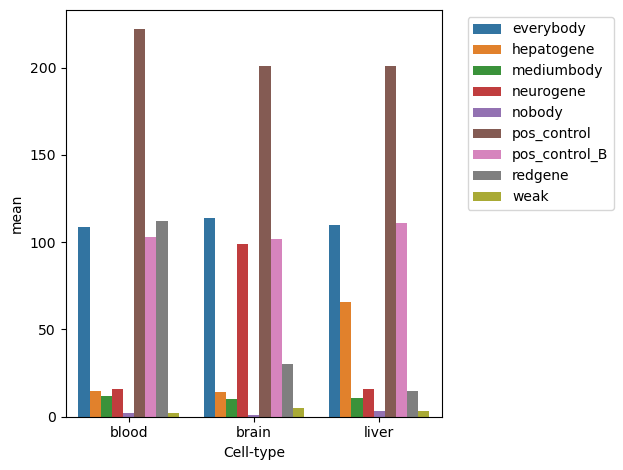

In [81]:
sns.barplot(cres,x="Cell-type",hue="CRE",y="mean")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()  # Adjust plot to fit everything nicely
plt.show()

In [82]:
#add variance column
np.random.seed(111111) # so it's the same every time
cres["variance_constant"] = [0.3]*len(cres)
cres["sigmasquare"]=cres["mean"]+cres["variance_constant"]*cres["mean"]**2

In [83]:
cres

,CRE,Cell-type,mean,variance_constant,sigmasquare
11,everybody,blood,109,0.3,3673.3
17,hepatogene,blood,15,0.3,82.5
10,mediumbody,blood,12,0.3,55.2
13,neurogene,blood,16,0.3,92.8
9,nobody,blood,2,0.3,3.2
15,pos_control,blood,222,0.3,15007.2
16,pos_control_B,blood,103,0.3,3285.7
12,redgene,blood,112,0.3,3875.2
14,weak,blood,2,0.3,3.2
2,everybody,brain,114,0.3,4012.8


In [84]:
#add alterantive parametrization
cres["r"]=cres["mean"]**2/(cres["sigmasquare"]-cres["mean"])#also equal to 1/cres["variance_constant"]
cres["p"]=cres["mean"]/cres["sigmasquare"]

In [85]:
cres

,CRE,Cell-type,mean,variance_constant,sigmasquare,r,p
11,everybody,blood,109,0.3,3673.3,3.333333,0.029674
17,hepatogene,blood,15,0.3,82.5,3.333333,0.181818
10,mediumbody,blood,12,0.3,55.2,3.333333,0.217391
13,neurogene,blood,16,0.3,92.8,3.333333,0.172414
9,nobody,blood,2,0.3,3.2,3.333333,0.625000
15,pos_control,blood,222,0.3,15007.2,3.333333,0.014793
16,pos_control_B,blood,103,0.3,3285.7,3.333333,0.031348
12,redgene,blood,112,0.3,3875.2,3.333333,0.028902
14,weak,blood,2,0.3,3.2,3.333333,0.625000
2,everybody,brain,114,0.3,4012.8,3.333333,0.028409


In [86]:
# at this point, we have all of the information that would be replicate-indepndent. 
# Let's duplicate the table vertically to simulate reps

total_reps=3
cres_duplicated = pd.concat([cres] * total_reps, ignore_index=True)
cres_duplicated['replicate_ID'] = [i + 1 for i in range(total_reps) for _ in range(len(cres))]

In [87]:
cres_duplicated

,CRE,Cell-type,mean,variance_constant,sigmasquare,r,p,replicate_ID
0,everybody,blood,109,0.3,3673.3,3.333333,0.029674,1
1,hepatogene,blood,15,0.3,82.5,3.333333,0.181818,1
2,mediumbody,blood,12,0.3,55.2,3.333333,0.217391,1
3,neurogene,blood,16,0.3,92.8,3.333333,0.172414,1
4,nobody,blood,2,0.3,3.2,3.333333,0.625000,1
...,...,...,...,...,...,...,...,...
76,nobody,liver,3,0.3,5.7,3.333333,0.526316,3
77,pos_control,liver,201,0.3,12321.3,3.333333,0.016313,3
78,pos_control_B,liver,111,0.3,3807.3,3.333333,0.029155,3
79,redgene,liver,15,0.3,82.5,3.333333,0.181818,3


In [88]:
cres=cres_duplicated

In [89]:
#let's pretend..
#In each replicate there were 1000 blood cells, 900 brain cells, 1200 liver cells, and transfection efficiency for each CRE ~ N(0.5,0.01)
#to be more sophisticated, we could introduce systemic differences in cell number, tfection efficiency btwn reps...
np.random.seed(413) # so it's the same every time
cres["transfection_efficiency"]=np.random.normal(loc=0.5, scale=0.01, size=len(cres))
#cc={"brain":900,"blood":1000,'liver':1200}
cc={"brain":10000,"blood":10000,"liver":10000}
cres["cells"]=cres["Cell-type"].map(cc)*cres["transfection_efficiency"]
cres["cells"]=cres["cells"].round().astype(int)

In [90]:

#add zero inflation column
#this represents dropout due to RNA degredation, etc
#RNA dropout for each CRE ~ N(x,0.01) for rep 1 x=0.1, rep 2 x=0.2, rep3 x=0.3

np.random.seed(413)

zeroinfl=[]
for infl in [0.1,0.2,0.3]:
    zeroinfl.append(np.random.normal(loc=infl, scale=0.01, size=int(len(cres)/3)))

cres["zeroinfl"]=np.concatenate(zeroinfl)


In [91]:
cres

,CRE,Cell-type,mean,variance_constant,sigmasquare,r,p,replicate_ID,transfection_efficiency,cells,zeroinfl
0,everybody,blood,109,0.3,3673.3,3.333333,0.029674,1,0.488506,4885,0.088506
1,hepatogene,blood,15,0.3,82.5,3.333333,0.181818,1,0.515676,5157,0.115676
2,mediumbody,blood,12,0.3,55.2,3.333333,0.217391,1,0.501541,5015,0.101541
3,neurogene,blood,16,0.3,92.8,3.333333,0.172414,1,0.492430,4924,0.092430
4,nobody,blood,2,0.3,3.2,3.333333,0.625000,1,0.516259,5163,0.116259
...,...,...,...,...,...,...,...,...,...,...,...
76,nobody,liver,3,0.3,5.7,3.333333,0.526316,3,0.496557,4966,0.296557
77,pos_control,liver,201,0.3,12321.3,3.333333,0.016313,3,0.487508,4875,0.287508
78,pos_control_B,liver,111,0.3,3807.3,3.333333,0.029155,3,0.505790,5058,0.305790
79,redgene,liver,15,0.3,82.5,3.333333,0.181818,3,0.490077,4901,0.290077


In [92]:
np.random.seed(612)
def wrapper(row):
    #print(type(row["cells"]))
    return draw_zinb(mu=row["mean"], sigma2=row["sigmasquare"], zin=row["zeroinfl"], size=row["cells"])

cres["draws"]=cres.apply(wrapper,axis=1)


In [93]:
cres

,CRE,Cell-type,mean,variance_constant,sigmasquare,r,p,replicate_ID,transfection_efficiency,cells,zeroinfl,draws
0,everybody,blood,109,0.3,3673.3,3.333333,0.029674,1,0.488506,4885,0.088506,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,hepatogene,blood,15,0.3,82.5,3.333333,0.181818,1,0.515676,5157,0.115676,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,mediumbody,blood,12,0.3,55.2,3.333333,0.217391,1,0.501541,5015,0.101541,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,neurogene,blood,16,0.3,92.8,3.333333,0.172414,1,0.492430,4924,0.092430,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,nobody,blood,2,0.3,3.2,3.333333,0.625000,1,0.516259,5163,0.116259,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...
76,nobody,liver,3,0.3,5.7,3.333333,0.526316,3,0.496557,4966,0.296557,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
77,pos_control,liver,201,0.3,12321.3,3.333333,0.016313,3,0.487508,4875,0.287508,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
78,pos_control_B,liver,111,0.3,3807.3,3.333333,0.029155,3,0.505790,5058,0.305790,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
79,redgene,liver,15,0.3,82.5,3.333333,0.181818,3,0.490077,4901,0.290077,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [94]:
#shuffle the draws to avoid having all the zeroes lumped together at the front
np.random.seed(413)
cres['draws'] = cres['draws'].apply(lambda x: list(np.random.permutation(x)))


In [95]:
#Subsetting to those data that will be accessible after the assay is performed.
cres_reduced=cres[["CRE","Cell-type","replicate_ID","draws","cells"]]

In [96]:
cres_reduced

,CRE,Cell-type,replicate_ID,draws,cells
0,everybody,blood,1,"[88, 62, 32, 202, 100, 175, 0, 107, 226, 83, 7...",4885
1,hepatogene,blood,1,"[14, 9, 3, 12, 0, 32, 4, 6, 0, 22, 12, 15, 9, ...",5157
2,mediumbody,blood,1,"[8, 14, 6, 15, 2, 16, 5, 0, 10, 13, 0, 0, 3, 2...",5015
3,neurogene,blood,1,"[1, 5, 16, 0, 25, 17, 12, 13, 6, 11, 12, 0, 29...",4924
4,nobody,blood,1,"[1, 0, 0, 7, 4, 0, 0, 5, 3, 0, 2, 1, 2, 4, 0, ...",5163
...,...,...,...,...,...
76,nobody,liver,3,"[0, 2, 0, 0, 3, 3, 2, 8, 1, 0, 1, 2, 1, 4, 1, ...",4966
77,pos_control,liver,3,"[145, 0, 78, 0, 189, 0, 84, 0, 95, 238, 142, 0...",4875
78,pos_control_B,liver,3,"[124, 134, 0, 0, 38, 0, 105, 93, 107, 134, 76,...",5058
79,redgene,liver,3,"[10, 0, 17, 12, 0, 13, 0, 2, 7, 14, 4, 26, 4, ...",4901


Now let's add cell_bc. Each combination of replicate, cell_id gets its own set of cell barcodes.

In [97]:
#for each combination of col values that represents one set of cells, we wish to get the max number of cells
cell_sets=cres_reduced.groupby(["Cell-type","replicate_ID"])['cells'].agg('max')
cell_sets

Cell-type  replicate_ID
blood      1               5163
           2               5234
           3               5294
brain      1               5217
           2               5092
           3               5163
liver      1               5074
           2               5227
           3               5104
Name: cells, dtype: int64

In [98]:
def generate_barcodes(length, count):
    if 4**length < count:
        raise ValueError("Not enough unique barcodes of given length.")

    digit_to_base = ['A', 'C', 'G', 'T']
    barcodes = []

    for i in range(count):
        barcode = []
        n = i
        for _ in range(length):
            barcode.append(digit_to_base[n % 4])
            n //= 4
        # If length not fully filled, pad with 'A's
        while len(barcode) < length:
            barcode.append('A')
        barcodes.append(''.join(reversed(barcode)))

    return barcodes

barcodes=generate_barcodes(16,cell_sets.sum())

In [99]:
def assign_barcodes(df, barcodes):
    assigned = []
    i = 0
    for num in df['cells']:
        assigned.append(barcodes[i : i + num])
        i += num
    df = df.copy()
    df['assigned_barcodes'] = assigned
    return df

assignation=assign_barcodes(pd.DataFrame(cell_sets).reset_index(),barcodes)

In [100]:
assignation

,Cell-type,replicate_ID,cells,assigned_barcodes
0,blood,1,5163,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
1,blood,2,5234,"[AAAAAAAAACCAAGGT, AAAAAAAAACCAAGTA, AAAAAAAAA..."
2,blood,3,5294,"[AAAAAAAAAGGAGCTC, AAAAAAAAAGGAGCTG, AAAAAAAAA..."
3,brain,1,5217,"[AAAAAAAAATTCCAGT, AAAAAAAAATTCCATA, AAAAAAAAA..."
4,brain,2,5092,"[AAAAAAAACCACGGTA, AAAAAAAACCACGGTC, AAAAAAAAC..."
5,brain,3,5163,"[AAAAAAAACGCCGCAA, AAAAAAAACGCCGCAC, AAAAAAAAC..."
6,liver,1,5074,"[AAAAAAAACTGCGTGT, AAAAAAAACTGCGTTA, AAAAAAAAC..."
7,liver,2,5227,"[AAAAAAAAGATCGATC, AAAAAAAAGATCGATG, AAAAAAAAG..."
8,liver,3,5104,"[AAAAAAAAGGACTTGA, AAAAAAAAGGACTTGC, AAAAAAAAG..."


In [101]:
assert all(assignation["assigned_barcodes"].apply(len)==assignation["cells"])

Nice! ok, let's add to cres_reduced

In [102]:
assignation=pd.merge(cres_reduced,assignation,how="left",on=["Cell-type","replicate_ID"])#.explode(['draws','assigned_barcodes']).reset_index(drop=True)
assignation

,CRE,Cell-type,replicate_ID,draws,cells_x,cells_y,assigned_barcodes
0,everybody,blood,1,"[88, 62, 32, 202, 100, 175, 0, 107, 226, 83, 7...",4885,5163,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
1,hepatogene,blood,1,"[14, 9, 3, 12, 0, 32, 4, 6, 0, 22, 12, 15, 9, ...",5157,5163,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
2,mediumbody,blood,1,"[8, 14, 6, 15, 2, 16, 5, 0, 10, 13, 0, 0, 3, 2...",5015,5163,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
3,neurogene,blood,1,"[1, 5, 16, 0, 25, 17, 12, 13, 6, 11, 12, 0, 29...",4924,5163,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
4,nobody,blood,1,"[1, 0, 0, 7, 4, 0, 0, 5, 3, 0, 2, 1, 2, 4, 0, ...",5163,5163,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
...,...,...,...,...,...,...,...
76,nobody,liver,3,"[0, 2, 0, 0, 3, 3, 2, 8, 1, 0, 1, 2, 1, 4, 1, ...",4966,5104,"[AAAAAAAAGGACTTGA, AAAAAAAAGGACTTGC, AAAAAAAAG..."
77,pos_control,liver,3,"[145, 0, 78, 0, 189, 0, 84, 0, 95, 238, 142, 0...",4875,5104,"[AAAAAAAAGGACTTGA, AAAAAAAAGGACTTGC, AAAAAAAAG..."
78,pos_control_B,liver,3,"[124, 134, 0, 0, 38, 0, 105, 93, 107, 134, 76,...",5058,5104,"[AAAAAAAAGGACTTGA, AAAAAAAAGGACTTGC, AAAAAAAAG..."
79,redgene,liver,3,"[10, 0, 17, 12, 0, 13, 0, 2, 7, 14, 4, 26, 4, ...",4901,5104,"[AAAAAAAAGGACTTGA, AAAAAAAAGGACTTGC, AAAAAAAAG..."


In [103]:
assignation=assignation.drop("cells_y",axis=1).rename({'cells_x':'cells'},axis=1)

In [104]:
def trunk(row):
    return row["assigned_barcodes"][0:row["cells"]]
assignation["assigned_barcodes"]=assignation.apply(trunk,axis=1)

In [105]:
assignation

,CRE,Cell-type,replicate_ID,draws,cells,assigned_barcodes
0,everybody,blood,1,"[88, 62, 32, 202, 100, 175, 0, 107, 226, 83, 7...",4885,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
1,hepatogene,blood,1,"[14, 9, 3, 12, 0, 32, 4, 6, 0, 22, 12, 15, 9, ...",5157,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
2,mediumbody,blood,1,"[8, 14, 6, 15, 2, 16, 5, 0, 10, 13, 0, 0, 3, 2...",5015,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
3,neurogene,blood,1,"[1, 5, 16, 0, 25, 17, 12, 13, 6, 11, 12, 0, 29...",4924,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
4,nobody,blood,1,"[1, 0, 0, 7, 4, 0, 0, 5, 3, 0, 2, 1, 2, 4, 0, ...",5163,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
...,...,...,...,...,...,...
76,nobody,liver,3,"[0, 2, 0, 0, 3, 3, 2, 8, 1, 0, 1, 2, 1, 4, 1, ...",4966,"[AAAAAAAAGGACTTGA, AAAAAAAAGGACTTGC, AAAAAAAAG..."
77,pos_control,liver,3,"[145, 0, 78, 0, 189, 0, 84, 0, 95, 238, 142, 0...",4875,"[AAAAAAAAGGACTTGA, AAAAAAAAGGACTTGC, AAAAAAAAG..."
78,pos_control_B,liver,3,"[124, 134, 0, 0, 38, 0, 105, 93, 107, 134, 76,...",5058,"[AAAAAAAAGGACTTGA, AAAAAAAAGGACTTGC, AAAAAAAAG..."
79,redgene,liver,3,"[10, 0, 17, 12, 0, 13, 0, 2, 7, 14, 4, 26, 4, ...",4901,"[AAAAAAAAGGACTTGA, AAAAAAAAGGACTTGC, AAAAAAAAG..."


In [106]:
cres_reduced=assignation.explode(['draws', 'assigned_barcodes']).reset_index(drop=True)

In [107]:
cres_reduced

,CRE,Cell-type,replicate_ID,draws,cells,assigned_barcodes
0,everybody,blood,1,88,4885,AAAAAAAAAAAAAAAA
1,everybody,blood,1,62,4885,AAAAAAAAAAAAAAAC
2,everybody,blood,1,32,4885,AAAAAAAAAAAAAAAG
3,everybody,blood,1,202,4885,AAAAAAAAAAAAAAAT
4,everybody,blood,1,100,4885,AAAAAAAAAAAAAACA
...,...,...,...,...,...,...
406398,weak,liver,3,4,4951,AAAAAAAAGTCCCAGG
406399,weak,liver,3,7,4951,AAAAAAAAGTCCCAGT
406400,weak,liver,3,1,4951,AAAAAAAAGTCCCATA
406401,weak,liver,3,4,4951,AAAAAAAAGTCCCATC


In [108]:
def check_barcode_uniqueness(df, group_by_col):
    from itertools import combinations

    grouped = df.groupby(group_by_col)['assigned_barcodes'].agg(set)

    for (group1, barcodes1), (group2, barcodes2) in combinations(grouped.items(), 2):
        overlap = barcodes1 & barcodes2
        if overlap:
            print(f"[!] Overlapping barcodes between {group1} and {group2}:")
            print(f"   {len(overlap)} overlapping barcodes (e.g. {list(overlap)[:5]})")
            return False

    print(f"[+] All {group_by_col} groups have unique barcode sets.")
    return True

assert check_barcode_uniqueness(cres_reduced,"Cell-type")
assert check_barcode_uniqueness(cres_reduced,"replicate_ID")

[+] All Cell-type groups have unique barcode sets.
[+] All replicate_ID groups have unique barcode sets.


In [109]:
#one we expect to have overlap:
assert not check_barcode_uniqueness(cres_reduced,"CRE")

[!] Overlapping barcodes between everybody and hepatogene:
   44932 overlapping barcodes (e.g. ['AAAAAAAAGTCCCGGC', 'AAAAAAAACTCAGTTG', 'AAAAAAAACGTATTCT', 'AAAAAAAACATTAAAA', 'AAAAAAAAAAGAAGCG'])


In [110]:
cres_reduced=cres_reduced.rename({'draws':'umis_mpra_bc','replicate_ID':'rep_id','assigned_barcodes':'cell_bc','CRE':'cre_id','Cell-type':'cell_type'},axis=1)[["cell_bc","rep_id","cre_id","cell_type","umis_mpra_bc"]]

In [111]:
cres_reduced

,cell_bc,rep_id,cre_id,cell_type,umis_mpra_bc
0,AAAAAAAAAAAAAAAA,1,everybody,blood,88
1,AAAAAAAAAAAAAAAC,1,everybody,blood,62
2,AAAAAAAAAAAAAAAG,1,everybody,blood,32
3,AAAAAAAAAAAAAAAT,1,everybody,blood,202
4,AAAAAAAAAAAAAACA,1,everybody,blood,100
...,...,...,...,...,...
406398,AAAAAAAAGTCCCAGG,3,weak,liver,4
406399,AAAAAAAAGTCCCAGT,3,weak,liver,7
406400,AAAAAAAAGTCCCATA,3,weak,liver,1
406401,AAAAAAAAGTCCCATC,3,weak,liver,4


In [112]:
agg=pd.DataFrame(cres_reduced.groupby(["cre_id","cell_type"])['umis_mpra_bc'].agg('sum')).reset_index()

In [113]:
agg

,cre_id,cell_type,umis_mpra_bc
0,everybody,blood,1304540
1,everybody,brain,1365138
2,everybody,liver,1308679
3,hepatogene,blood,179803
4,hepatogene,brain,167849
5,hepatogene,liver,798200
6,mediumbody,blood,143743
7,mediumbody,brain,119117
8,mediumbody,liver,131191
9,neurogene,blood,193018


<Axes: xlabel='cell_type', ylabel='umis_mpra_bc'>

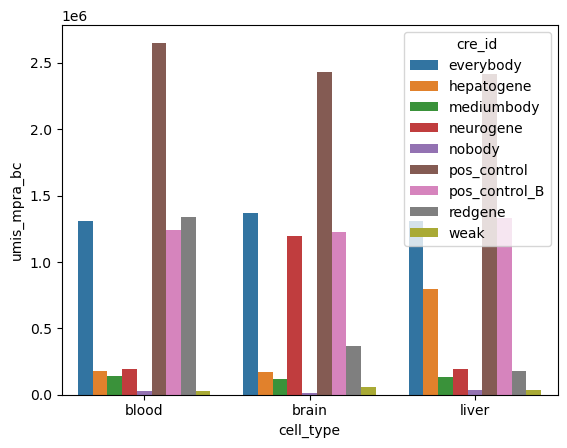

In [114]:
sns.barplot(agg.sort_values(by=["cell_type","cre_id"]),x="cell_type",hue="cre_id",y="umis_mpra_bc")

In [115]:
cres_reduced.to_csv("/gpfs/gibbs/pi/reilly/tabula_data/simulated/fake_cres_v3_10000.tsv",sep="\t")